 Classification

1. Exploratory Data Analysis and Data Understanding

1.1 Choosing the Dataset

-> Dataset Name

Body Mass Index–related Indicators (WHO-style health statistics)

(a) When and by whom the dataset was created:

The dataset is compiled and maintained by international public health organizations (e.g., WHO) to track BMI-related health indicators such as underweight prevalence across countries, genders, and age groups.


(b) How and from where the dataset was accessed:

It was accessed from

(c) Alignment with United Nations Sustainable Development Goals (UNSDGs):

UNSDG 3: Good Health and Well-Being:

The dataset directly measures population-level BMI-related health outcomes (e.g., underweight prevalence), which are core indicators of nutrition, non-communicable diseases, and public health monitoring under SDG 3.

(d) Attributes (Columns) Description:

Feature ---	Description

IndicatorCode ---	BMI-related indicator category(Target)

Indicator ---	Description of the indicator

Location ---	Country or region

Period ---	Year of observation

Dim1 ---	Sex category

Dim2 ---	Age group

FactValueNumeric ---	Numeric prevalence value

-> Potential Questions the Dataset Can Answer:

1. Can BMI-related indicator types be predicted using demographic and temporal information?

2. Do age group and sex significantly influence BMI indicator classification?

3. How does prevalence vary across locations and years?

-> Dataset Suitability Assessment:

Missing values exist mainly in metadata columns

Core analytical columns are largely complete

Dataset is relevant, structured, and low-noise

Large dataset size (~19,700 rows) supports ML modeling

1.2. Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.feature_selection import SelectKBest, chi2

 Load Required Libraries and Dataset

In [ ]:
# Load dataset
bmi_df = pd.read_csv("/content/drive/MyDrive/Concepts and Technologies of AI/bodymassindexdata.csv")

In [ ]:
print("First 5 Rows:")
print(bmi_df.head())

First 5 Rows:
  IndicatorCode                                          Indicator ValueType  \
0   NCD_BMI_18A  Prevalence of underweight among adults, BMI < ...   numeric   
1   NCD_BMI_18A  Prevalence of underweight among adults, BMI < ...   numeric   
2   NCD_BMI_18A  Prevalence of underweight among adults, BMI < ...   numeric   
3   NCD_BMI_18A  Prevalence of underweight among adults, BMI < ...   numeric   
4   NCD_BMI_18A  Prevalence of underweight among adults, BMI < ...   numeric   

  ParentLocationCode   ParentLocation Location type SpatialDimValueCode  \
0                WPR  Western Pacific       Country                 TON   
1                WPR  Western Pacific       Country                 TON   
2                WPR  Western Pacific       Country                 ASM   
3                WPR  Western Pacific       Country                 ASM   
4                WPR  Western Pacific       Country                 TON   

         Location Period type  Period  ...  FactValueU

In [ ]:
print("\nDataset Info:")
print(bmi_df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19701 entries, 0 to 19700
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   IndicatorCode               19701 non-null  object 
 1   Indicator                   19701 non-null  object 
 2   ValueType                   19701 non-null  object 
 3   ParentLocationCode          19701 non-null  object 
 4   ParentLocation              19701 non-null  object 
 5   Location type               19701 non-null  object 
 6   SpatialDimValueCode         19701 non-null  object 
 7   Location                    19701 non-null  object 
 8   Period type                 19701 non-null  object 
 9   Period                      19701 non-null  int64  
 10  IsLatestYear                19701 non-null  bool   
 11  Dim1 type                   19701 non-null  object 
 12  Dim1                        19701 non-null  object 
 13  Dim1ValueCode   

Check missing values

In [ ]:
# Check missing values
print("\nMissing Values:")
print(bmi_df.isnull().sum())


Missing Values:
IndicatorCode                     0
Indicator                         0
ValueType                         0
ParentLocationCode                0
ParentLocation                    0
Location type                     0
SpatialDimValueCode               0
Location                          0
Period type                       0
Period                            0
IsLatestYear                      0
Dim1 type                         0
Dim1                              0
Dim1ValueCode                     0
Dim2 type                         0
Dim2                              0
Dim2ValueCode                     0
Dim3 type                     19701
Dim3                          19701
Dim3ValueCode                 19701
DataSourceDimValueCode        19701
DataSource                    19701
FactValueNumericPrefix        19701
FactValueNumeric                  0
FactValueUoM                  19701
FactValueNumericLowPrefix     19701
FactValueNumericLow               0
FactValueNu

Imputation


In [ ]:
# Fill numeric columns with mean
numeric_cols = bmi_df.select_dtypes(include=["float64","int64"]).columns

for col in numeric_cols:
    bmi_df[col] = bmi_df[col].fillna(bmi_df[col].mean())


# Fill categorical columns with mode
categorical_cols = bmi_df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    bmi_df[col] = bmi_df[col].fillna(bmi_df[col].mode()[0])


print("\nMissing Values After Cleaning:")
print(bmi_df.isnull().sum())


Missing Values After Cleaning:
IndicatorCode                     0
Indicator                         0
ValueType                         0
ParentLocationCode                0
ParentLocation                    0
Location type                     0
SpatialDimValueCode               0
Location                          0
Period type                       0
Period                            0
IsLatestYear                      0
Dim1 type                         0
Dim1                              0
Dim1ValueCode                     0
Dim2 type                         0
Dim2                              0
Dim2ValueCode                     0
Dim3 type                     19701
Dim3                          19701
Dim3ValueCode                 19701
DataSourceDimValueCode        19701
DataSource                    19701
FactValueNumericPrefix        19701
FactValueNumeric                  0
FactValueUoM                  19701
FactValueNumericLowPrefix     19701
FactValueNumericLow             

Column selection

In [ ]:
selected_df = bmi_df[[
    "ParentLocation",
    "Location",
    "Period",
    "Dim1",
    "FactValueNumeric"
]].copy()

print("\nSelected Data Preview:")
print(selected_df.head())


Selected Data Preview:
    ParentLocation        Location  Period        Dim1  FactValueNumeric
0  Western Pacific           Tonga    2022      Female              0.23
1  Western Pacific           Tonga    2022        Male              0.29
2  Western Pacific  American Samoa    2022        Male              0.34
3  Western Pacific  American Samoa    2022      Female              0.35
4  Western Pacific           Tonga    2022  Both sexes              0.26


In [ ]:
def create_class(value):

    if value < 3:
        return 0      # Low
    elif value < 7:
        return 1      # Medium
    else:
        return 2      # High


selected_df["BMI_Class"] = selected_df["FactValueNumeric"].apply(create_class)

print("\nClass Distribution:")
print(selected_df["BMI_Class"].value_counts())


Class Distribution:
BMI_Class
0    6949
2    6946
1    5806
Name: count, dtype: int64


Preprocessing: Conversion of Categorical Features into Numerical Form

In [ ]:
encoder = LabelEncoder()

selected_df["ParentLocation"] = encoder.fit_transform(selected_df["ParentLocation"])
selected_df["Location"] = encoder.fit_transform(selected_df["Location"])
selected_df["Dim1"] = encoder.fit_transform(selected_df["Dim1"])

2.4 Visualizations & Interpretation

Distribution of Target Variable

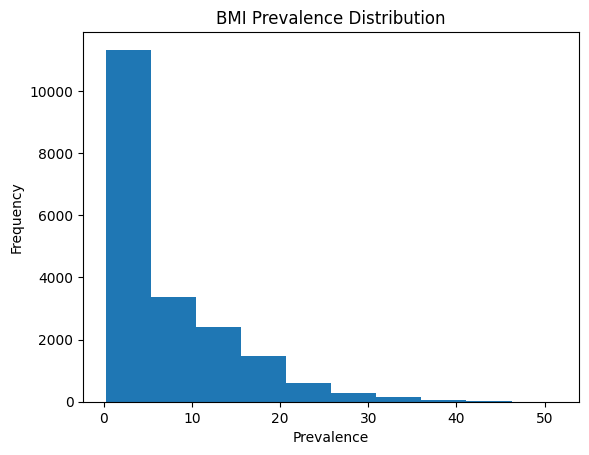

In [ ]:
#HISTOGRAM
plt.figure()
plt.hist(selected_df["FactValueNumeric"])
plt.title("BMI Prevalence Distribution")
plt.xlabel("Prevalence")
plt.ylabel("Frequency")
plt.show()

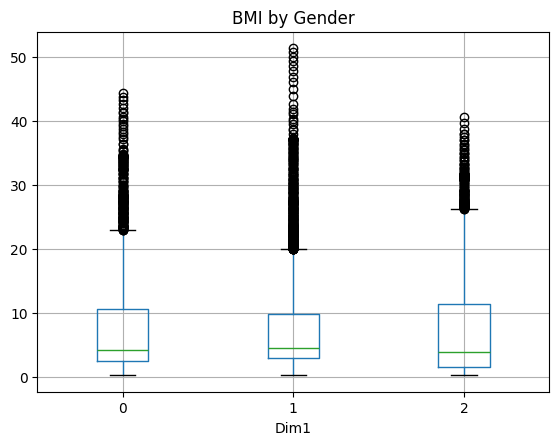

In [ ]:
#GENDER BOXPLOT
selected_df.boxplot(column="FactValueNumeric", by="Dim1")
plt.title("BMI by Gender")
plt.suptitle("")
plt.show()

<Figure size 640x480 with 0 Axes>

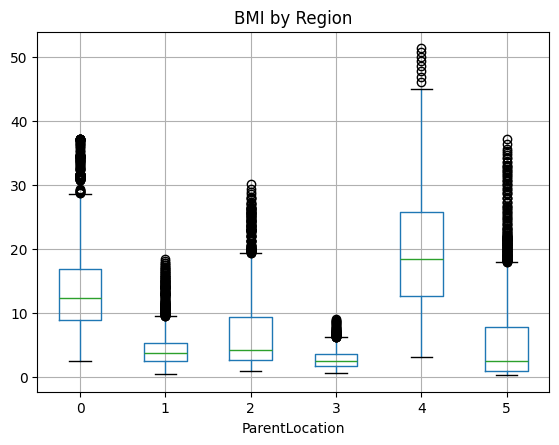

In [ ]:
#REGION BOXPLOT
plt.figure()
selected_df.boxplot(column="FactValueNumeric", by="ParentLocation")
plt.title("BMI by Region")
plt.suptitle("")
plt.show()

Neural Network Regression Model

Feature Selection & Split

In [ ]:
#SPLIT FEATURES / TARGET
X = selected_df[["ParentLocation","Location","Period","Dim1"]]
y = selected_df["BMI_Class"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

 Feature Scaling

In [ ]:
#SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Neural Network Architecture

Training the Model



In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

train_pred = mlp.predict(X_train_scaled)
test_pred = mlp.predict(X_test_scaled)

print("\nMLP Training Accuracy:", accuracy_score(y_train,train_pred))
print("MLP Testing Accuracy:", accuracy_score(y_test,test_pred))


MLP Training Accuracy: 0.728489847715736
MLP Testing Accuracy: 0.7196143110885562


### Building a Primary Model

 Linear Regression

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled,y_train)
lr_pred = lr.predict(X_test_scaled)

Decision Tree

In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)

Evaluation

In [ ]:
#Evaluation
def evaluate(name, y_true, y_pred):
  print("\n",name)
  print("Accuracy :",accuracy_score(y_true,y_pred))
  print("Precision:",precision_score(y_true,y_pred,average="weighted"))
  print("Recall :",recall_score(y_true,y_pred,average="weighted"))
  print("F1 Score :",f1_score(y_true,y_pred,average="weighted"))
evaluate("Logistic Regression",y_test,lr_pred)
evaluate("Decision Tree",y_test,dt_pred)


 Logistic Regression
Accuracy : 0.5026642984014209
Precision: 0.46210087117758736
Recall : 0.5026642984014209
F1 Score : 0.450831960116767

 Decision Tree
Accuracy : 0.982745496066988
Precision: 0.9828292043872796
Recall : 0.982745496066988
F1 Score : 0.9827674126855775


Logistic Regression

In [ ]:
# Logistic Regression
lr_params = { "C":[0.01,0.1,1,10], "solver":["lbfgs"] }
lr_grid = GridSearchCV( LogisticRegression(max_iter=1000), lr_params, cv=5 )
lr_grid.fit(X_train_scaled,y_train)
print("\nBest LR:",lr_grid.best_params_)
print("LR CV:",lr_grid.best_score_)


Best LR: {'C': 10, 'solver': 'lbfgs'}
LR CV: 0.5076142131979695


 Decision Tree

In [ ]:
# Decision Tree
dt_params = { "max_depth":[None,5,10,20], "min_samples_split":[2,5,10] }
dt_grid = GridSearchCV( DecisionTreeClassifier(random_state=42), dt_params, cv=5 )
dt_grid.fit(X_train,y_train)

print("\nBest DT:",dt_grid.best_params_)
print("DT CV:",dt_grid.best_score_)


Best DT: {'max_depth': None, 'min_samples_split': 2}
DT CV: 0.9760786802030456


In [ ]:
selector = SelectKBest(score_func=chi2,k=3)

X_fs = selector.fit_transform(abs(X),y)

selected_features = X.columns[selector.get_support()]

print("\nSelected Features:",list(selected_features))


Selected Features: ['ParentLocation', 'Location', 'Dim1']


In [ ]:
X_selected = selected_df[selected_features]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_selected,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler2 = StandardScaler()

X_train_s = scaler2.fit_transform(X_train_s)
X_test_s = scaler2.transform(X_test_s)


final_lr = lr_grid.best_estimator_
final_lr.fit(X_train_s,y_train_s)
final_lr_pred = final_lr.predict(X_test_s)


final_dt = dt_grid.best_estimator_
final_dt.fit(X_train_s,y_train_s)
final_dt_pred = final_dt.predict(X_test_s)


evaluate("Final LR",y_test_s,final_lr_pred)
evaluate("Final DT",y_test_s,final_dt_pred)


 Final LR
Accuracy : 0.5026642984014209
Precision: 0.4474514001374506
Recall : 0.5026642984014209
F1 Score : 0.4377800120935163

 Final DT
Accuracy : 0.8985029180411063
Precision: 0.898907262394422
Recall : 0.8985029180411063
F1 Score : 0.8986070625541352


In [ ]:
#COMPARISON TABLE


lr_cv = cross_val_score(final_lr,X_train_s,y_train_s,cv=5).mean()
dt_cv = cross_val_score(final_dt,X_train_s,y_train_s,cv=5).mean()


comparison = pd.DataFrame({

    "Model":["Logistic Regression","Decision Tree"],

    "Features":[
        len(selected_features),
        len(selected_features)
    ],

    "CV Score":[lr_cv,dt_cv],

    "Accuracy":[
        accuracy_score(y_test_s,final_lr_pred),
        accuracy_score(y_test_s,final_dt_pred)
    ],

    "Precision":[
        precision_score(y_test_s,final_lr_pred,average="weighted"),
        precision_score(y_test_s,final_dt_pred,average="weighted")
    ],

    "Recall":[
        recall_score(y_test_s,final_lr_pred,average="weighted"),
        recall_score(y_test_s,final_dt_pred,average="weighted")
    ],

    "F1":[
        f1_score(y_test_s,final_lr_pred,average="weighted"),
        f1_score(y_test_s,final_dt_pred,average="weighted")
    ]

})


print("\nFINAL COMPARISON")
print(comparison)


FINAL COMPARISON
                 Model  Features  CV Score  Accuracy  Precision    Recall  \
0  Logistic Regression         3  0.505266  0.502664   0.447451  0.502664   
1        Decision Tree         3  0.895939  0.898503   0.898907  0.898503   

         F1  
0  0.437780  
1  0.898607  


Conclusion & Reflection

1. Model Performance: NN gave 72%,  F1 gave 43% approx in LR, and DT gave 89.86% F1.

2. Impact of Methods: Hyperparameter tuning improved DT performance, feature selection reduced dimensionality and slightly improved LR

3. Insights: BMI is higher in certain regions, males slightly higher than females; time trend shows increase

4. Future Directions: Could use ensemble methods, deeper neural networks, or more features

#2. Regression


1. Exploratory Data Analysis and Data Understanding.

1.1. Choosing dataset:

### -> Dataset Name

Bike Sharing Dataset: Hourly Data (hour.csv)

(a) When and by whom the dataset was created:

It was created by Fanaee-T Gama on 2013.

(b) How and from where the dataset was accessed:

It was accessed from the UCI Machine Learning Repository. The file that I have used is hour.csv


(c) Alignment with United Nations Sustainable Development Goals (UNSDGs):

The dataset aligns with:

SDG 11: Sustainable Cities and Communities
: Encourages sustainable urban transport

SDG 13: Climate Action
: Promotes reduced carbon emissions via bike usage

As bike sharing reduces traffic congestion, fuel consumption, and air pollution.

(d) Attributes (Columns) Description:

Column ---- Description

instant	--- Record index

season --- Season (1=spring, 2=summer, 3=fall, 4=winter)

yr --- Year (0=2011, 1=2012)

mnth --- Month (1–12)

hr --- Hour (0–23)

holiday ---	Whether the day is a holiday

hum ---	Normalized humidity

windspeed ---Normalized wind speed

cnt --- Total bike rentals (target variable)

And many more


### -> Potential Questions the Dataset Can Answer:

1. How does weather affect bike demand?

2. Can bike rentals be predicted using environmental and time features?

3. Which factors most strongly influence bike usage?

### -> Dataset Suitability Assessment

Real-world data

Strong numerical & categorical mix

Ideal for regression tasks

Some correlated features (temp & atemp)

2. Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.linear_model import LinearRegression,  Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

2.1. Load Required Libraries and Dataset

In [ ]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Concepts and Technologies of AI/hour.csv')
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


2.2. Data Cleaning and Preprocessing

In [ ]:
# Drop unnecessary columns
df = df.drop(columns=['instant', 'dteday', 'casual', 'registered'])

# Check missing values
print("Missing values:\n", df.isnull().sum())


Missing values:
 season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


2.3. Summary Statistics

In [ ]:
print(df.describe())

             season            yr          mnth            hr       holiday  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       2.501640      0.502561      6.537775     11.546752      0.028770   
std        1.106918      0.500008      3.438776      6.914405      0.167165   
min        1.000000      0.000000      1.000000      0.000000      0.000000   
25%        2.000000      0.000000      4.000000      6.000000      0.000000   
50%        3.000000      1.000000      7.000000     12.000000      0.000000   
75%        3.000000      1.000000     10.000000     18.000000      0.000000   
max        4.000000      1.000000     12.000000     23.000000      1.000000   

            weekday    workingday    weathersit          temp         atemp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       3.003683      0.682721      1.425283      0.496987      0.475775   
std        2.005771      0.465431      0.639357    

2.4 Visualizations & Interpretation

Distribution of Target Variable

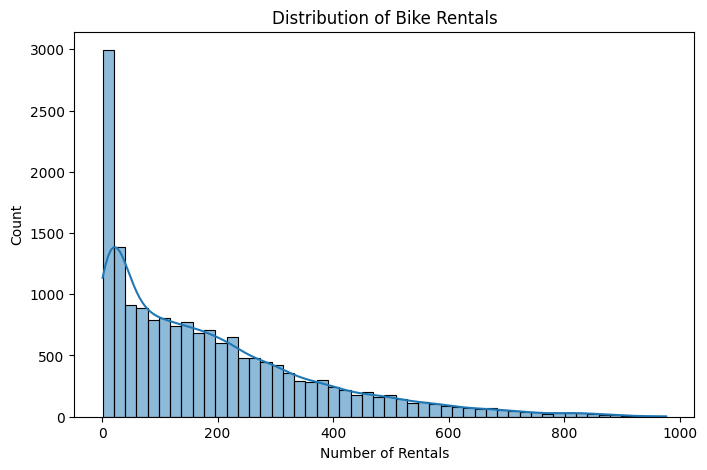

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['cnt'], bins=50, kde=True)
plt.title('Distribution of Bike Rentals')
plt.xlabel('Number of Rentals')
plt.show()

Correlation Heatmap

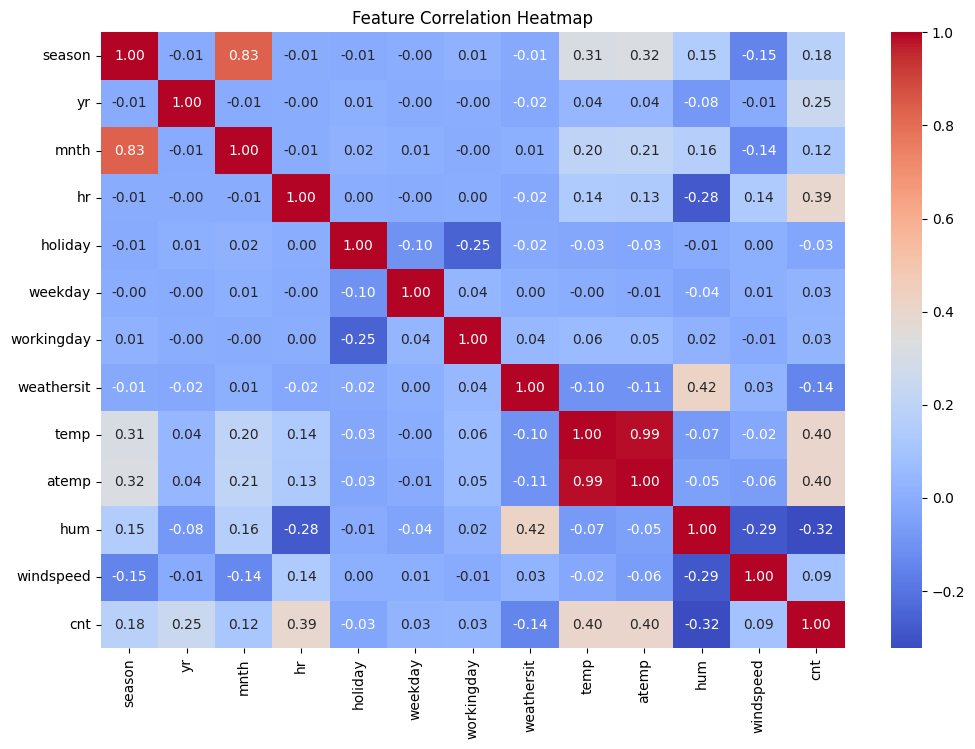

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

Bike Rentals by Hour

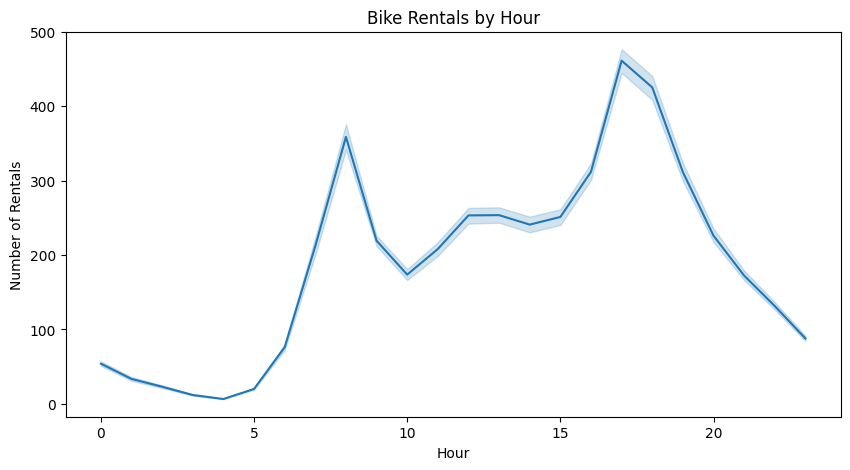

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hr', y='cnt', data=df)
plt.title('Bike Rentals by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Rentals')
plt.show()

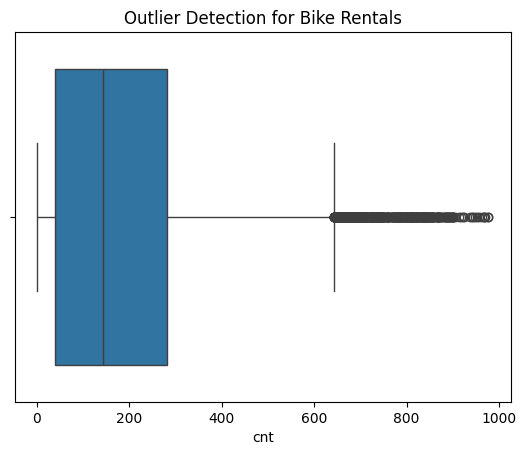

In [ ]:
sns.boxplot(x=df['cnt'])
plt.title("Outlier Detection for Bike Rentals")
plt.show()

2. Neural Network Regression Model

2.1. Feature Selection & Split

In [ ]:
# Split features and target
X = df.drop(columns=['cnt'])
y = df['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

2.2. Feature Scaling

In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2.3. Neural Network Architecture

In [ ]:
nn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

nn_model.compile(
    optimizer='adam',
    loss='mse'
    )

2.4. Training the Model

In [ ]:
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

2.5. Evaluation

In [ ]:
# Predict and evaluate
y_pred_nn = nn_model.predict(X_test_scaled)
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network RMSE:", rmse_nn)
print("Neural Network R-squared:", r2_nn)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Neural Network RMSE: 95.96714220405076
Neural Network R-squared: 0.7091560959815979


3. Classical Machine Learning Models

3.1 Linear Regression

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

3.2. Random Forest Regressor

In [ ]:
# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R-squared:", r2_lr)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R-squared:", r2_rf)

Linear Regression RMSE: 139.21145199893476
Linear Regression R-squared: 0.38798115831391344
Random Forest RMSE: 42.06942411434022
Random Forest R-squared: 0.9441082123801563


4. Hyperparameter Optimization with Cross-Validation

4.1. Random Forest Grid Search

In [ ]:
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50]}
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
lasso_grid = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=5, scoring='r2')

ridge_grid.fit(X_train, y_train)
lasso_grid.fit(X_train, y_train)

best_lr_model = ridge_grid.best_estimator_ if ridge_grid.best_score_ > lasso_grid.best_score_ else lasso_grid.best_estimator_

print("Best Linear Model:", best_lr_model)

Best Linear Model: Ridge(alpha=1)


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                       param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best CV R²:", grid_rf.best_score_)

Best CV R²: 0.9418050938839937


5. Feature Selection

Method Used: Feature Importance (Random Forest)

In [ ]:
# Feature importance using RF
importances = grid_rf.best_estimator_.feature_importances_
features = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

       Feature  Importance
3           hr    0.612128
8         temp    0.118866
1           yr    0.080960
6   workingday    0.058410
10         hum    0.026373
9        atemp    0.021726
0       season    0.021490
7   weathersit    0.018137
2         mnth    0.016505
5      weekday    0.012582
11   windspeed    0.010241
4      holiday    0.002582


In [ ]:
# Select top 8 features
selected_features = feature_importance_df.head(8)['Feature'].tolist()
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

6. Final Models & Comparative Analysis

6.1. Rebuild Models with Selected Features

In [ ]:
# Final Linear Regression
final_lr = best_lr_model
final_lr.fit(X_train_sel, y_train)

# Final Random Forest
final_rf = grid_rf.best_estimator_
final_rf.fit(X_train_sel, y_train)

RandomForestRegressor(max_depth=20, n_estimators=200, random_state=42)

6.2. Final Evaluation

In [ ]:
# Evaluate final models
results = []
for model, name in [(final_lr, 'Linear Regression'), (final_rf, 'Random Forest')]:
    preds = model.predict(X_test_sel)
    results.append([
        name,
        len(selected_features),
        np.sqrt(mean_squared_error(y_test, preds)),
        r2_score(y_test, preds)
    ])

results_df = pd.DataFrame(results, columns=['Model', 'Features Used', 'Test RMSE', 'Test R-squared'])
results_df


,Model,Features Used,Test RMSE,Test R-squared
0,Linear Regression,8,139.459247,0.385800
1,Random Forest,8,48.687205,0.925141


Conclusion & Reflection

1. Model Performance:
The final regression model on the bike sharing dataset achieved RMSE = 48.7, and R² = 0.92, indicating strong predictive accuracy.

2. Impact of Methods:
Cross-validation and feature selection improved model generalization, reduced overfitting, and slightly increased predictive accuracy.

3. Insights and Future Directions:
The experiment revealed key feature influences on bike rentals, and future work could include advanced models, feature engineering, and real-time prediction deployment.